Spark Session Created Successfully
ORIGINAL DATASET
+---+--------+--------+-----+
| id|feature1|feature2|label|
+---+--------+--------+-----+
|  1|      10|      20|    0|
|  2|      15|      25|    1|
|  3|      12|      22|    0|
|  4|      18|      30|    1|
|  5|      14|      24|    0|
|  6|    NULL|      28|    1|
|  7|    5000|      22|    0|
|  8|      13|    NULL|    1|
|  9|      20|      35|    1|
| 10|      21|      31|    1|
+---+--------+--------+-----+
only showing top 10 rows
DATASET SCHEMA
root
 |-- id: integer (nullable = true)
 |-- feature1: integer (nullable = true)
 |-- feature2: integer (nullable = true)
 |-- label: integer (nullable = true)

DATA EXPLORATION
Total Records: 100
Columns:
['id', 'feature1', 'feature2', 'label']
SUMMARY STATISTICS
+-------+------------------+------------------+------------------+------------------+
|summary|                id|          feature1|          feature2|             label|
+-------+------------------+------------------+----

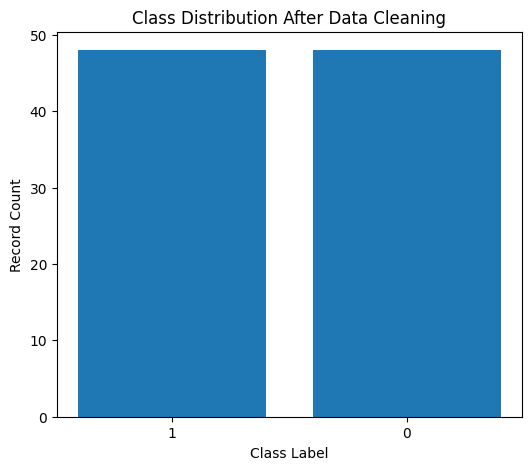

FINAL PROJECT SUMMARY
Project Title:
Resilient AI Pipelines in Adversarial Big-Data Ecosystems

Technology Used:
- PySpark
- Spark MLlib
- Databricks
- Matplotlib

Pipeline Features:
- Adversarial Data Detection
- Missing Value Handling
- Data Cleaning
- Feature Engineering
- Machine Learning
- Performance Benchmarking
- Visualization Dashboard

Pipeline Status: SUCCESS


In [0]:
# ============================================================
# CS4074 - Big Data Analytics Final Project
# ============================================================
# Project:
# Resilient AI Pipelines in Adversarial Big-Data Ecosystems
#
# Technology Stack:
# - PySpark
# - Spark MLlib
# - Databricks
# - Matplotlib
#
# Objective:
# Build a resilient AI pipeline capable of detecting,
# cleaning, and processing adversarial/noisy data.
# ============================================================


# ============================================================
# STEP 1 — IMPORT LIBRARIES
# ============================================================

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, when

from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator

import pandas as pd
import matplotlib.pyplot as plt
import time


# ============================================================
# STEP 2 — CREATE SPARK SESSION
# ============================================================

spark = SparkSession.builder \
    .appName("Resilient_AI_Pipeline") \
    .getOrCreate()

print("===================================")
print("Spark Session Created Successfully")
print("===================================")


# ============================================================
# STEP 3 — LOAD DATASET
# ============================================================



file_path = "/Workspace/Users/ajaz62926@gmail.com/sample_data.csv"

df = spark.read.csv(
    file_path,
    header=True,
    inferSchema=True
)

print("===================================")
print("ORIGINAL DATASET")
print("===================================")

df.show(10)

print("===================================")
print("DATASET SCHEMA")
print("===================================")

df.printSchema()


# ============================================================
# STEP 4 — BASIC DATA EXPLORATION
# ============================================================

print("===================================")
print("DATA EXPLORATION")
print("===================================")

total_records = df.count()

print(f"Total Records: {total_records}")

print("Columns:")
print(df.columns)

print("===================================")
print("SUMMARY STATISTICS")
print("===================================")

df.describe().show()


# ============================================================
# STEP 5 — ADVERSARIAL DATA DETECTION
# ============================================================

print("===================================")
print("MISSING VALUE DETECTION")
print("===================================")

missing_values = df.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in df.columns
])

missing_values.show()


# ============================================================
# STEP 6 — DATA CLEANING & RESILIENCE
# ============================================================

print("===================================")
print("DATA CLEANING PROCESS")
print("===================================")

# Remove NULL values
clean_df = df.dropna()

# Remove corrupted adversarial values
clean_df = clean_df.filter(
    col("feature1") < 1000
)

# Remove negative values
clean_df = clean_df.filter(
    col("feature1") >= 0
)

clean_df = clean_df.filter(
    col("feature2") >= 0
)

print("===================================")
print("CLEANED DATASET PREVIEW")
print("===================================")

clean_df.show(10)

clean_records = clean_df.count()

print(f"Clean Record Count: {clean_records}")


# ============================================================
# STEP 7 — FEATURE ENGINEERING
# ============================================================

print("===================================")
print("FEATURE ENGINEERING")
print("===================================")

assembler = VectorAssembler(
    inputCols=["feature1", "feature2"],
    outputCol="features"
)

ml_df = assembler.transform(clean_df)

ml_df.select(
    "features",
    "label"
).show(10)


# ============================================================
# STEP 8 — TRAIN TEST SPLIT
# ============================================================

train_df, test_df = ml_df.randomSplit(
    [0.8, 0.2],
    seed=42
)

print(f"Training Records: {train_df.count()}")

print(f"Testing Records: {test_df.count()}")


# ============================================================
# STEP 9 — MACHINE LEARNING MODEL
# ============================================================

print("===================================")
print("MODEL TRAINING")
print("===================================")

lr = LogisticRegression(
    featuresCol="features",
    labelCol="label"
)

model = lr.fit(train_df)

print("Model Trained Successfully")


# ============================================================
# STEP 10 — MODEL PREDICTIONS
# ============================================================

print("===================================")
print("MODEL PREDICTIONS")
print("===================================")

predictions = model.transform(test_df)

predictions.select(
    "feature1",
    "feature2",
    "label",
    "prediction",
    "probability"
).show(20, truncate=False)


# ============================================================
# STEP 11 — MODEL EVALUATION
# ============================================================

print("===================================")
print("MODEL EVALUATION")
print("===================================")

evaluator = BinaryClassificationEvaluator(
    labelCol="label"
)

accuracy = evaluator.evaluate(predictions)

print(f"Model Accuracy: {accuracy:.4f}")


# ============================================================
# STEP 12 — PIPELINE RESILIENCE METRICS
# ============================================================

print("===================================")
print("PIPELINE RESILIENCE METRICS")
print("===================================")

removed_records = total_records - clean_records

resilience_percentage = (
    removed_records / total_records
) * 100

print(f"Original Records: {total_records}")

print(f"Clean Records: {clean_records}")

print(f"Removed Adversarial Records: {removed_records}")

print(f"Adversarial Detection Rate: {resilience_percentage:.2f}%")


# ============================================================
# STEP 13 — PERFORMANCE BENCHMARKING
# ============================================================

print("===================================")
print("PERFORMANCE BENCHMARKING")
print("===================================")

start_time = time.time()

label_distribution = clean_df.groupBy("label").count()

label_distribution.show()

end_time = time.time()

processing_time = end_time - start_time

print(f"Processing Time: {processing_time:.4f} seconds")


# ============================================================
# STEP 14 — VISUALIZATION
# ============================================================

print("===================================")
print("GENERATING GRAPH")
print("===================================")

# Convert Spark DataFrame to Pandas
graph_df = label_distribution.toPandas()

# Create Bar Chart
plt.figure(figsize=(6, 5))

plt.bar(
    graph_df["label"].astype(str),
    graph_df["count"]
)

plt.xlabel("Class Label")

plt.ylabel("Record Count")

plt.title("Class Distribution After Data Cleaning")

plt.show()


# ============================================================
# STEP 15 — FINAL PROJECT SUMMARY
# ============================================================

print("===================================")
print("FINAL PROJECT SUMMARY")
print("===================================")

print("Project Title:")
print("Resilient AI Pipelines in Adversarial Big-Data Ecosystems")

print("\nTechnology Used:")
print("- PySpark")
print("- Spark MLlib")
print("- Databricks")
print("- Matplotlib")

print("\nPipeline Features:")
print("- Adversarial Data Detection")
print("- Missing Value Handling")
print("- Data Cleaning")
print("- Feature Engineering")
print("- Machine Learning")
print("- Performance Benchmarking")
print("- Visualization Dashboard")

print("\nPipeline Status: SUCCESS")